## The Noise Schedule

In [2]:
import torch
import matplotlib.pyplot as plt

In [3]:
T = 1000
def make_noise_schedule(T, beta_start, beta_end):
    betas = torch.linspace(beta_start, beta_end, T)
    alphas = 1 - betas
    alphas_bar = torch.cumprod(alphas, dim=0)

    return (betas, alphas, alphas_bar)

In [4]:
betas, alphas, alphas_bar = make_noise_schedule(T, beta_start=1e-4, beta_end=0.02)

In [5]:
import numpy as np

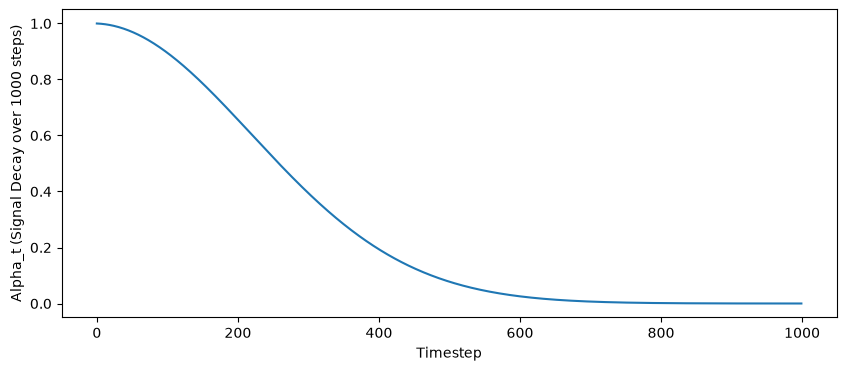

In [6]:
plt.figure(figsize=(10, 4))
plt.plot(range(T), alphas_bar.numpy())
plt.xlabel("Timestep")
plt.ylabel("Alpha_t (Signal Decay over 1000 steps)")
plt.show()

## The Forward Process

In [7]:
from sklearn.datasets import load_breast_cancer

In [8]:
real_data = load_breast_cancer()

In [12]:
X = real_data.data

In [13]:
from sklearn.preprocessing import StandardScaler

In [14]:
scaler = StandardScaler()

In [15]:
X_scaled = scaler.fit_transform(X)

In [16]:
from torch.utils.data import DataLoader, TensorDataset

In [17]:
X_scaled_tensor = torch.tensor(X_scaled, dtype=torch.float32)

In [19]:
print(X_scaled_tensor.shape)

torch.Size([569, 30])


## The Forward Process Function

In [29]:
def forward_process(X_scaled_tensor, T, alphas_bar):
    # Sample random noise the same shape as x_0
    random_noise = torch.randn_like(X_scaled_tensor)

    # Extract $\sqrt{\bar{\alpha}_t}$ for each row in the batch

    alphas_bar_row = alphas_bar[T].reshape(-1, 1)
    corrupt_data = alphas_bar_row.sqrt() * X_scaled_tensor + (1- alphas_bar_row).sqrt() * random_noise

    return (corrupt_data, random_noise)

    




In [30]:
test_steps = torch.tensor([0, 500, 999])
x_sample = X_scaled_tensor[:3]
corrupt_data, random_noise = forward_process(x_sample, test_steps, alphas_bar)

print("Step 0   (almost clean):", corrupt_data[0][:5])
print("Step 500 (half corrupted):", corrupt_data[1][:5])
print("Step 999 (pure noise):", corrupt_data[2][:5])


Step 0   (almost clean): tensor([ 1.1123, -2.0777,  1.2720,  0.9918,  1.5800])
Step 500 (half corrupted): tensor([ 0.3712, -0.0294, -0.0602,  0.1371, -2.1135])
Step 999 (pure noise): tensor([ 1.2451, -0.0959, -0.3140,  0.4872,  0.8425])


## The Denoiser Network

In [31]:
import torch.nn as nn

In [37]:
from ray._private import resource_isolation_config
from ray._private import resource_isolation_config
from ray._private import resource_isolation_config
class Denoiser(nn.Module):
    def __init__(self, T):
        super().__init__()
        self.time_embed = nn.Embedding(T, 128)
        self.fc1 = nn.Linear(158, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, 30)
        self.relu = nn.ReLU()

    def forward(self, corrupt_data, T):
        t_emb = self.time_embed(T)
        x = torch.cat([corrupt_data, t_emb], dim= 1)
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        
        return self.fc3(x)

model = Denoiser(T)
print(model)

Denoiser(
  (time_embed): Embedding(1000, 128)
  (fc1): Linear(in_features=158, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=128, bias=True)
  (fc3): Linear(in_features=128, out_features=30, bias=True)
  (relu): ReLU()
)


## The Training Loop

In [38]:
import torch.optim as optim
import torch.nn.functional as F

In [39]:
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 4000
batch_size = 128

In [ ]:
for epoch in range(epochs):
    batch_indices = torch.randint(0, len(X_scaled_tensor), (batch_size,))
    t = torch.randint(0, T, (batch_size,))
    X = X_scaled_tensor[batch_indices]

   

    corrupt_data, random_noise = forward_process(X, t, alphas_bar)
    optimizer.zero_grad()
    predicted_noise = model(corrupt_data, t)
    loss = F.mse_loss(predicted_noise, random_noise)
    loss.backward()
    optimizer.step()
    
    if epoch % 500 == 0:
        print(f"Epoch {epoch} | Loss: {loss.item():.5f}")








Epoch 0 | Loss: 0.15914
Epoch 500 | Loss: 0.15278
Epoch 1000 | Loss: 0.16098
Epoch 1500 | Loss: 0.15311
Epoch 2000 | Loss: 0.17654
Epoch 2500 | Loss: 0.14467
Epoch 3000 | Loss: 0.15104
Epoch 3500 | Loss: 0.13099


## The Reverse Process (Sampling)

In [56]:
def generate_samples(num_sample, model):
    X = torch.randn(num_sample, 30)

    for i in reversed(range(T)):
        t = torch.full((num_sample,), i, dtype=torch.long)
        with torch.no_grad():
            predicted_noise = model(X, t)
            alpha_t = alphas[i]
            alphas_bar_t = alphas_bar[i]
            beta_t = betas[i]
            
            scaling_factor = 1.0 / torch.sqrt(alpha_t)

            noise_subtraction = X - (beta_t / torch.sqrt(1.0 - alphas_bar_t)) * predicted_noise

            X = scaling_factor * noise_subtraction

            if i > 0:
                z = torch.randn_like(X)
                sigma_t = torch.sqrt(beta_t)
                X = X + sigma_t * z
            return X

In [58]:
synthetic_data = generate_samples(5, model)
print(synthetic_data)

tensor([[-1.2708e+00,  1.4053e-01,  1.0536e+00,  1.2908e+00,  4.3806e-02,
         -1.2851e+00, -6.5308e-01, -9.8778e-01, -8.6638e-01, -5.0869e-01,
          1.6592e+00, -6.2207e-01, -1.0233e+00,  6.6208e-01, -3.6659e-01,
          3.4221e-01, -7.9980e-01, -6.5835e-01,  2.9576e-01, -1.2753e+00,
         -4.5829e-01,  1.5343e+00,  1.8839e+00, -2.8711e-02,  3.0651e-01,
          7.0426e-02, -5.7524e-01, -2.1020e+00,  4.2927e-01, -2.2166e-01],
        [ 1.9950e+00,  1.4177e+00,  4.9347e-02, -2.4210e-01, -1.1371e+00,
         -8.9965e-01, -1.0941e+00,  9.4444e-01, -5.5855e-01, -5.7578e-01,
          1.9950e+00, -8.6318e-01,  1.8074e-01, -1.4927e+00,  5.8486e-02,
          5.7512e-01,  4.7261e-01, -2.9368e-01, -3.8959e-01, -2.5345e-01,
         -1.5852e+00, -3.8810e-01, -8.3441e-01,  2.0329e+00,  8.2103e-01,
          6.1780e-01,  6.9449e-02,  7.0144e-01, -1.7933e-01, -9.0888e-01],
        [ 4.8068e-01, -5.9357e-01, -1.0821e+00,  2.3701e-01,  3.1534e-01,
         -5.6115e-01,  6.4081e-01,  

In [59]:
synthetic_numpy = synthetic_data.numpy()

In [60]:
synthetic_real_world = scaler.inverse_transform(synthetic_numpy)


In [61]:
print("First synthetic patient (real scale):")
print(synthetic_real_world[0][:5])

First synthetic patient (real scale):
[9.6527901e+00 1.9893524e+01 1.1754801e+02 1.1087264e+03 9.6975833e-02]


In [62]:
torch.save(model.state_dict(), "tabddpm_model.pth")
